# TP - Performances LoRaWAN

Ce TP est à réaliser après le mini projet. Nous vous demanderons un rapport ainsi que les courbes tracées grâce à ce TP.
Vous n'êtes pas obligés de faire tourner ce notebook sur la Raspberry Pi utilisée pendant le Mini Projet.

Dans ce TP, vous allez réaliser une étude sur le **Facteur d'Étalement** (*Spreading Factor* ou **SF**) de LoRaWAN.

Vous utiliserez le module LoRa Mote de microchip que vous avez déjà utilisé dans les TP précédents.
Ainsi, nous vous encourageons à réutiliser les fonctions développées dans le cadre du mini projet et à les importer ci-dessous.

Montrez dans votre étude que vous avez compris ce que vous faites, les commentaires sont encouragés.

Si vous n'arrivez pas à utiliser la bibliothèque Paho MQTT pour récupérer les trames, vous pouvez les récupérer manuellement et les enregistrer dans un fichier vous-mêmes.

## Ressources

### RN2483
Documentation du module RN2483 :
https://ww1.microchip.com/downloads/en/DeviceDoc/RN2483-LoRa-Technology-Module-Command-Reference-User-Guide-DS40001784G.pdf

Ressources externes :
https://github.com/CampusIoT/tutorial/blob/master/rn2483/README.md

### Paho MQTT

Vous devrez utiliser la librairie Paho MQTT sous python afin de pouvoir vous **connecter au broker MQTT**, **subscribe au topic** et **enregistrer les trames**.

Documentation : https://pypi.org/project/paho-mqtt/  
Guide/Tutoriel : https://www.hivemq.com/blog/mqtt-client-library-paho-python/

### Seaborn

Afin de réaliser les courbes, nous vous proposons d'utiliser seaborn. Vous pouvez utiliser autre chose si vous le souhaitez, mais seaborn est une bibliothèque assez simple d'utilisation et haut niveau.

Documentation : https://seaborn.pydata.org/

### JSON

Les trames récupérées via MQTT sont dans le format JSON. Vous pouvez utiliser la bibliothèque json pour travailler avec ce format.   

Documentation : https://docs.python.org/3/library/json.html  
Tutoriel simple : https://opensource.com/article/19/7/save-and-load-data-python-json

#### /!\ Attention /!\
Si vous décidez d'utiliser la Raspberry Pi, voici les solutions à certains problèmes rencontrés par vos camarades durant le projet :

* Impossible de se connecter au jupyter notebook => Quand ça arrive, je recrée un venv : `python3 -m venv venv2`. N'oubliez pas de modifier la ligne `include-system-site-packages = false` en `include-system-site-packages = true` dans le fichier `venv2/pyenv.cfg` avant de le sourcer.
* Pour éviter un temps de téléchargement trop long quand vous essayez d'installer des paquets, mettez la Raspberry Pi à l'heure à l'aide de :  
`sudo date --set 'YYYY-MM-DD HH:mm:ss' `

# Import et installation

In [ ]:
#Import serial
try:
  import serial
except:
  !pip install pyserial
  import serial

In [ ]:
#Import Paho mqtt
try:
  import paho.mqtt.client as paho
except:
  %pip install paho-mqtt
  import paho.mqtt.client as paho

In [ ]:
#Import seaborn
try:
  import seaborn as sns
except:
  !pip install seaborn
  import seaborn as snslsnr


In [ ]:
#Import json
import json
import time
import logging

## Exemple seaborn

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


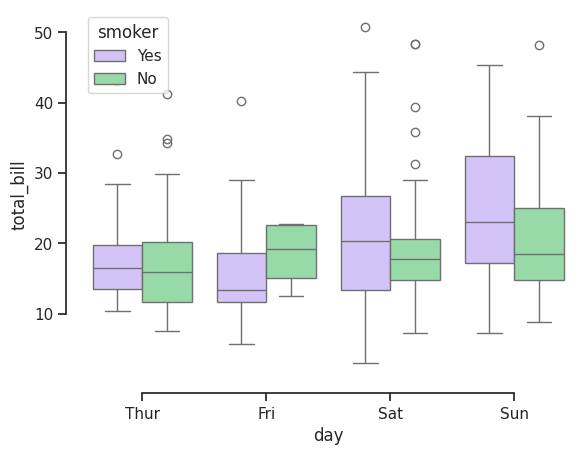

In [ ]:
sns.set_theme(style="ticks", palette="pastel")

# Load the example tips dataset
tips = sns.load_dataset("tips")
print(tips)

# Draw a nested boxplot to show bills by day and time
sns.boxplot(x="day", y="total_bill",
            hue="smoker", palette=["m", "g"],
            data=tips)
sns.despine(offset=10, trim=True)

# Questions préliminaires

**Qu'est-ce que le SF ?**

**Qu'est-ce que le RSSI ? Quelle est son unité ? Pourquoi est-ce important dans ce TP ?**

**Qu'est-ce que le SNR ? Quelle est son unité ? Pourquoi est-ce important dans ce TP ?**

# Partie 1 : Récupération de trames.
Dans cette partie, récupérez une trentaine de trames LoRaWAN pour chaque SF. Enregistrez les dans un fichier pour pouvoir les réutiliser dans la partie 2.


Rappel :  
Le LoRa Network Server (ou LNS) est configuré pour publier les messages reçus vers le topic :
`TestTopic/lora/{appid}/{deveui}/{event}`  
A l'aide de mosquitto_sub, vous allez **subscribe** à ce topic depuis une console grâce à la commande suivante :  
`mosquitto_sub -h neocampus.univ-tlse3.fr -t TestTopic/lora/{appid}/{deveui}/# -p 1882 -u test -P test`

Le broker MQTT neOCampus utilise le port 1882. En général, les brokers MQTT utilisent le port 1883. On précise le broker grâce à l'argument `-p` dans la commande ci dessus.
**Si vous essayez d'accéder au broker depuis un réseau externe à l'université, il faudra utiliser le port 10882**

# Partie 2 : Analyse
Dans cette partie, vous allez réutiliser les trames enregistrées lors de la partie 1.  
Quand vous traitez les trames, intéressez vous aux valeurs de la **best_gateway**.  

Si le résultat que vous obtenez n'est pas celui auquel vous vous attendiez, essayez de justifier pourquoi.

## RSSI

**Selon vous,quel comportement est attendu du RSSI quand on fait varier le SF ?**

On attend un RSSI qui augmente avec le SF.

**Tracez un graphe *(boxplot)* du RSSI en fonction du SF.**

/tmp/ipykernel_4692/2809967077.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, y="RSSI", x="SF", palette="Set2")


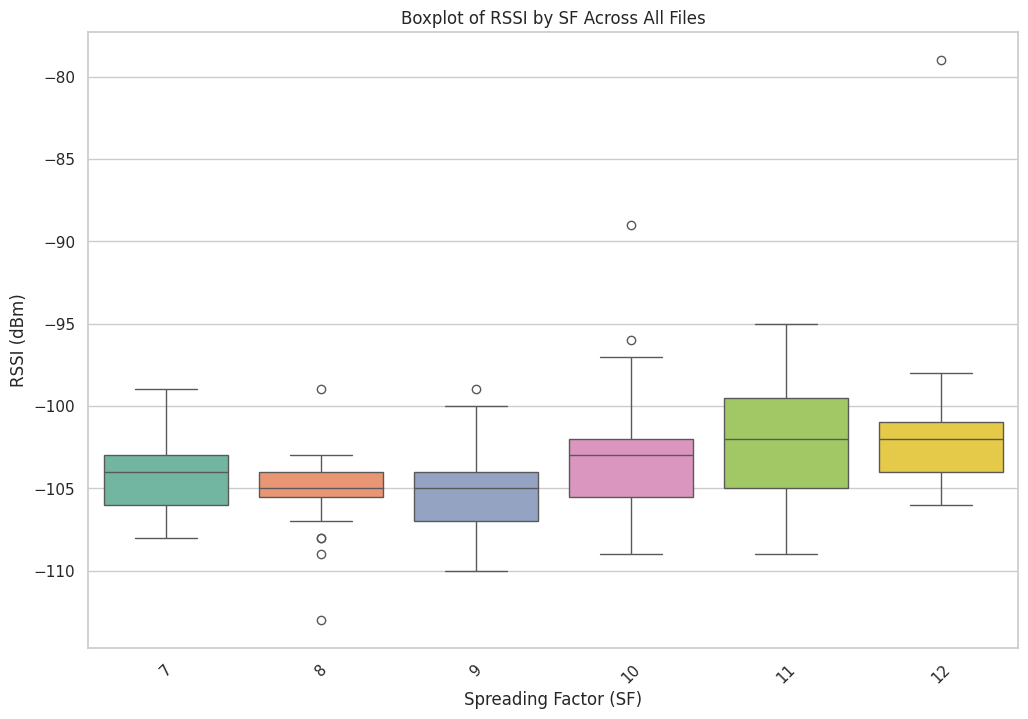

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Fichiers JSON contenant les trames collectées
file_paths = [
    'TP_json_files/sf7.json',
    'TP_json_files/sf8.json',
    'TP_json_files/sf9.json',
    'TP_json_files/sf10.json',
    'TP_json_files/sf11.json',
    'TP_json_files/sf12.json',
]

# Lecture et extraction des données depuis les fichiers JSON
all_data = []
for path in file_paths:
    with open(path, 'r') as file:
        data = json.load(file)
        for record in data:
            best_gw = record.get("best_gw", {})
            rssi = best_gw.get("rssi")
            datr = record.get("datr")
            # Extraction du SF (Spreading Factor) à partir du champ 'datr'
            if datr.startswith("SF")and datr[2:4].isdigit():
                sf = int(datr[2:4])  # Extraction de la valeur du SF (par exemple, "SF12BW125" -> 12)
                all_data.append({"RSSI": rssi, "SF": sf})
            else:
                sf = int(datr[2:3])
                all_data.append({"RSSI": rssi, "SF": sf})

# Création d'un DataFrame à partir des données extraites
df_combined = pd.DataFrame(all_data)

# Affichage des données extraites (df_combined)
# Création du boxplot du RSSI en fonction du SF
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_combined, y="RSSI", x="SF", palette="Set2")
plt.title("Boxplot of RSSI by SF Across All Files")
plt.suptitle("")
plt.xlabel("Spreading Factor (SF)")
plt.ylabel("RSSI (dBm)")
plt.xticks(rotation=45)
plt.show()


**Commentez le graphe. Que pouvez vous conclure ? Est-ce ce à quoi vous vous attendiez ? Pourquoi ?**

Variation des valeurs RSSI en fonction du SF : Les valeurs de RSSI (exprimées en dBm) présentent une certaine variabilité pour chaque Spreading Factor (SF).

On observe que le RSSI tend à légèrement augmenter avec le SF, ce qui correspond aux attentes. Toutefois, l’écart entre les différentes valeurs de SF est beaucoup plus faible que prévu.

Cela peut s’expliquer par le fait que les mesures proviennent de la meilleure gateway (best gateway), qui est souvent la plus proche. Ainsi, les résultats restent stables malgré les variations du SF.

## SNR

Selon vous,quel comportement est attendu du SNR quand on fait varier le SF ?

**Tracez un graphe *(boxplot)* du SNR en fonction du SF.**

/tmp/ipykernel_4692/1098146003.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, y="LSNR", x="SF", palette="Set2")


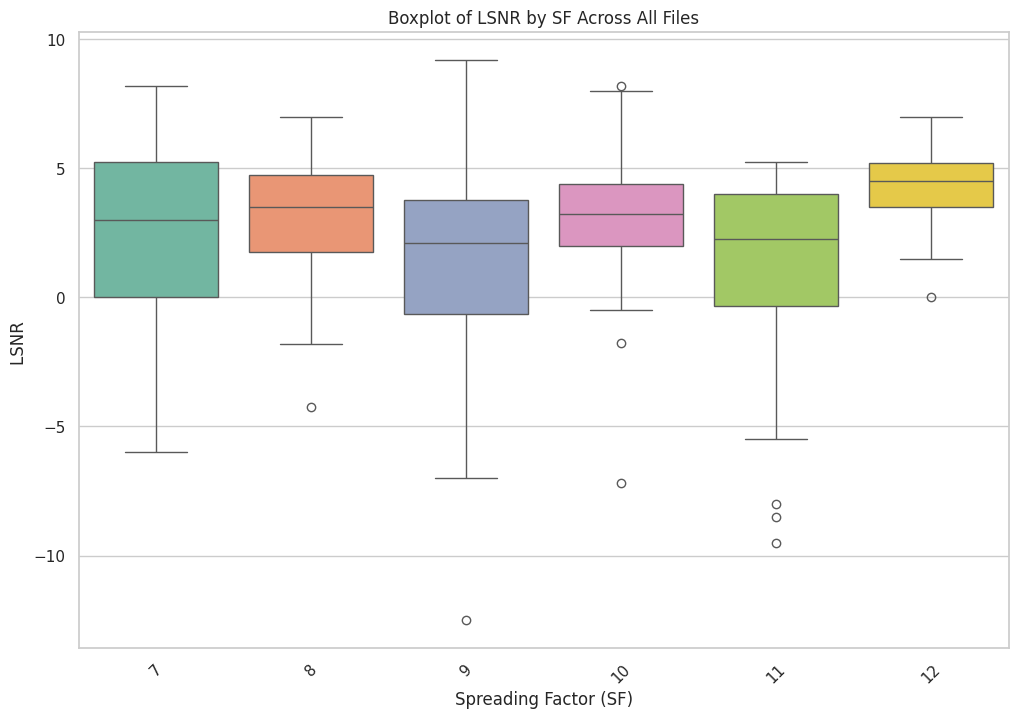

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Liste des chemins des fichiers JSON
file_paths = [
    'TP_json_files/sf7.json',
    'TP_json_files/sf8.json',
    'TP_json_files/sf9.json',
    'TP_json_files/sf10.json',
    'TP_json_files/sf11.json',
    'TP_json_files/sf12.json',
]

# Charger et extraire les données de chaque fichier JSON
all_data = []
for path in file_paths:
    with open(path, 'r') as file:
        data = json.load(file)
        for record in data:
            best_gw = record.get("best_gw", {})
            lsnr = best_gw.get("lsnr")
            datr = record.get("datr")
            # Extraction du SF (Spreading Factor) à partir du champ 'datr'
            if datr.startswith("SF")and datr[2:4].isdigit():
                sf = int(datr[2:4])  # Extraction de la valeur du SF (par exemple, "SF12BW125" -> 12)
                all_data.append({"LSNR": lsnr, "SF": sf})
            else:
                sf = int(datr[2:3])
                all_data.append({"LSNR": lsnr, "SF": sf})

# Créer un DataFrame à partir des données extraites
df_combined = pd.DataFrame(all_data)
# Affichage des données extraites (df_combined)
# Création du boxplot du RSSI en fonction du SF
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_combined, y="LSNR", x="SF", palette="Set2")
plt.title("Boxplot of LSNR by SF Across All Files")
plt.suptitle("")
plt.xlabel("Spreading Factor (SF)")
plt.ylabel("LSNR ")
plt.xticks(rotation=45)
plt.show()


**Commentez le graphe. Que pouvez vous conclure ? Est-ce ce à quoi vous vous attendiez ? Pourquoi ?**

## Data Extraction Rate de chaque gateway pour chaque SF
Dans cette partie, on vous demande le % de messages captés par chaque gateway pour chaque SF.

**Selon vous, que va entrainer la modification du SF ? Quel SF utiliser pour maximiser le DER ?**

**Tracez un graphe *(boxplot)* du DER de chaque gateway en fonction du SF.**

In [ ]:
import json


# Liste des chemins vers les fichiers JSON
file_paths = [
    'TP_json_files/sf7.json',
    'TP_json_files/sf8.json',
    'TP_json_files/sf9.json',
    'TP_json_files/sf10.json',
    'TP_json_files/sf11.json',
    'TP_json_files/sf12.json',
]

# Charger et extraire les données de chaque fichier
all_data = []
for path in file_paths:
    with open(path, 'r') as file:
        data = json.load(file)
        for record in data:
            all_gw = record.get("all_gw", [])  # Liste des gateways captant le message
            datr = record.get("datr")  # Facteur d'étalement (SF)
            if datr.startswith("SF") and datr[2:4].isdigit():
                sf = int(datr[2:4])  # Extraire le SF (par exemple, "SF12BW125" -> 12)
                for gw in all_gw:
                    gateway_desc = gw.get("desc", "Unknown")  # Description de la gateway
                    all_data.append({"SF": sf, "Gateway": gateway_desc})
            else:
                sf = int(datr[2:3])  # Extraire le SF (par exemple, "SF12BW125" -> 12)
                for gw in all_gw:
                    gateway_desc = gw.get("desc", "Unknown")  # Description de la gateway
                    all_data.append({"SF": sf, "Gateway": gateway_desc})



# Création d'un DataFrame à partir des données extraites
df = pd.DataFrame(all_data)

# Vérification des données extraites
print("Aperçu des données :")
print(df.head())
# Calcul du nombre total de messages reçus par chaque gateway pour chaque SF
message_counts = df.groupby(["SF", "Gateway"]).size().reset_index(name="MessageCount")
print(message_counts)


Aperçu des données :
   SF                                            Gateway
0   7         [eCOnect] Jetson nano + PyGate @ IRIT2-460
1   7  Mikrotik LtAP LR8 (Jean-Louis Druilhe) @IRIT2-366
2   7               MTCDTIP-266A / LoRa gateway @ Ecolab
3   7         [eCOnect] Jetson nano + PyGate @ IRIT2-460
4   7            MTCDT-210A / LoRa gateway @ BU sciences
    SF                                            Gateway  MessageCount
0    7               MTCDT-210A / LoRa gateway @ BU santé            14
1    7            MTCDT-210A / LoRa gateway @ BU sciences            19
2    7               MTCDTIP-266A / LoRa gateway @ Ecolab            21
3    7  Mikrotik LtAP LR8 (Jean-Louis Druilhe) @IRIT2-366            30
4    7         [eCOnect] Jetson nano + PyGate @ IRIT2-460            33
5    8               MTCDT-210A / LoRa gateway @ BU santé            19
6    8            MTCDT-210A / LoRa gateway @ BU sciences            22
7    8               MTCDTIP-266A / LoRa gateway @ Ecolab    

In [ ]:
# Ajout du pourcentage de messages captés par chaque gateway pour chaque SF
total_messages_per_sf = message_counts.groupby("SF")["MessageCount"].transform("sum")
message_counts["Percentage"] = (message_counts["MessageCount"] / total_messages_per_sf) * 100

# Affichage des résultats finaux
print("Pourcentage des messages captés par chaque gateway pour chaque SF :")
print(message_counts["Percentage"])

Pourcentage des messages captés par chaque gateway pour chaque SF :
0     11.965812
1     16.239316
2     17.948718
3     25.641026
4     28.205128
5     15.447154
6     17.886179
7     19.512195
8     24.390244
9     22.764228
10    13.559322
11    16.949153
12    16.949153
13    26.271186
14    26.271186
15    14.864865
16    19.594595
17    22.297297
18    21.621622
19    21.621622
20    16.260163
21    16.260163
22    19.512195
23    22.764228
24    25.203252
25    16.814159
26    19.469027
27    19.469027
28    22.123894
29    22.123894
Name: Percentage, dtype: float64


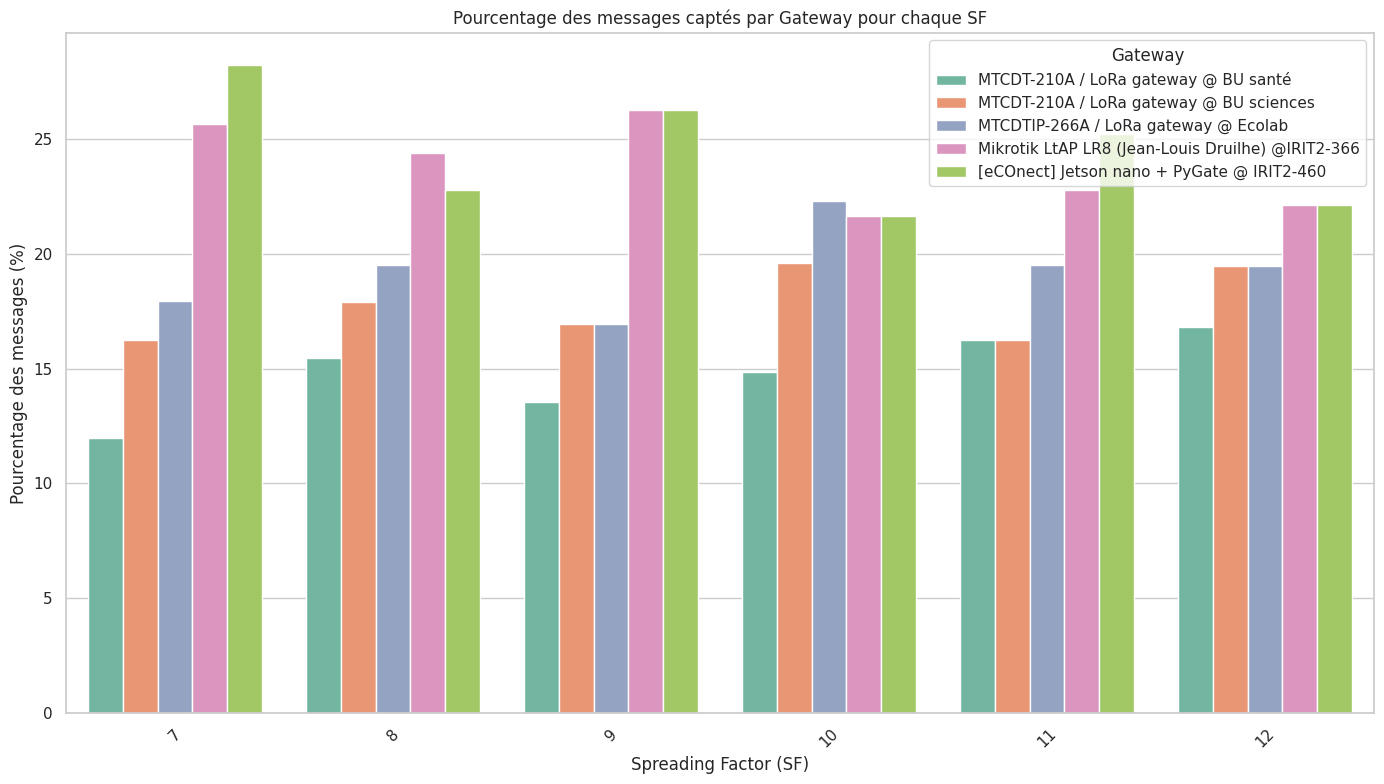

In [ ]:
# Visualisation des données avec Seaborn (Barplot groupé)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

sns.barplot(
    data=message_counts,
    x="SF",          # Axe X : SF
    y="Percentage",  # Axe Y : Pourcentage des messages
    hue="Gateway",   # Groupement par Gateway
    palette="Set2"   # Palette des couleurs
)

# Ajustements esthétiques pour améliorer la lisibilité du graphique
plt.title("Pourcentage des messages captés par Gateway pour chaque SF")
plt.xlabel("Spreading Factor (SF)")
plt.ylabel("Pourcentage des messages (%)")
plt.legend(title="Gateway", loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()

# Afficher le graphique
plt.show()

**Commentez le graphe. Que pouvez vous conclure ? Est-ce ce à quoi vous vous attendiez ? Pourquoi ?**

On observe qu'avec un SF bas ou haut, les gateways proches captent la majorité des messages, ce qui reflète leur meilleure sensibilité ou proximité. En revanche, un SF moyen  elevé permet une répartition plus équilibrée et favorise une meilleure réception par les gateways plus éloignées, optimisant ainsi la couverture globale.

# Distance

Le lien ci-dessous permet de voir où sont situées les gateways.  
**A quelle distance étiez vous des gateways quand vous émettiez ?**

https://www.google.com/maps/d/u/0/edit?mid=1oBEwKLwUyCBqnEczIpG0BARMm9NM1a0&usp=sharing


- MTCDTIP-266A / LoRa gateway @ Ecolab : 500m
- [eCOnect] Jetson nano + PyGate @ IRIT2-4600 : 5m
- MTCDT-210A / LoRa gateway @ BU sciences : 380m
- Mikrotik LtAP LR8 (Jean-Louis Druilhe) @IRIT2-366 : 150m
- MTCDT-210A / LoRa gateway @ BU santé : 1200km

**La distance joue-t-elle un rôle sur le RSSI et le SNR ? Expliquez.**

**La distance joue-t-elle un rôle dans le choix du SF ? Que pouvez vous en conclure ?**

Oui, la distance joue un rôle important dans le choix du SF. Un SF faible est adapté aux courtes distances pour maximiser le débit, tandis qu’un SF élevé est nécessaire pour les longues distances afin de garantir une meilleure portée et une réception fiable.

Conclusion : Le choix du SF doit être adapté à la distance entre l’émetteur et la gateway pour équilibrer portée, débit et qualité de réception.

**En plus du SF, pouvez vous citer d'autres paramètres importants afin d'optimiser les transmissions LoRaWAN ?**